In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
data = {
    "Experience":[1,2,3,4,5,6,7,8,9,10],
    "Salary":[30000,35000,40000,45000,50000,60000,65000,70000,75000,80000]
}

In [3]:
df=pd.DataFrame(data)

In [4]:
df

,Experience,Salary
0,1,30000
1,2,35000
2,3,40000
3,4,45000
4,5,50000
5,6,60000
6,7,65000
7,8,70000
8,9,75000
9,10,80000


In [5]:
X=df[["Experience"]]
y=df.Salary

In [6]:
# Train test splict 
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [7]:
# Standrazing the data set 
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

In [8]:
X_train = scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [9]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

In [10]:
reg=LinearRegression()
reg.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [11]:
# Perform 10-fold cross-validation (negative MSE)
mse = cross_val_score(reg, X_train, y_train, cv=5, scoring='neg_mean_squared_error')

In [12]:
np.mean(mse)

np.float64(-2834573.2570547685)

In [13]:
predict_reg=reg.predict(X_test)

In [14]:
predict_reg

array([74839.10891089, 34554.45544554, 57574.25742574])

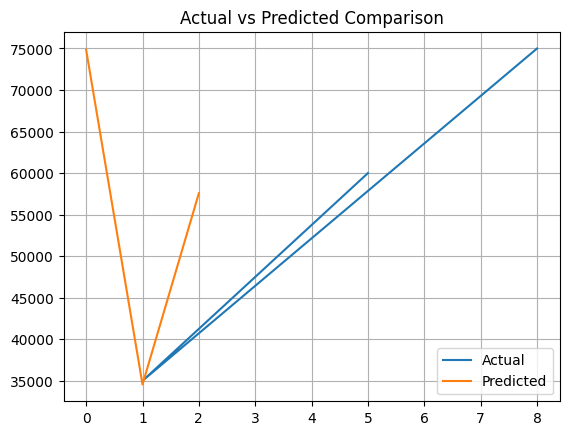

In [15]:
plt.plot(y_test, label="Actual")
plt.plot(predict_reg, label="Predicted")

plt.legend()
plt.title("Actual vs Predicted Comparison")
plt.grid()
plt.show()